# Experimento 2: Auditoría del Modelo MTDE-Net usando Grad-CAM
Este notebook implementa **Grad-CAM (Gradient-weighted Class Activation Mapping)** para el modelo multimodal `MTDE-Net` con el fin de visualizar qué regiones de la imagen térmica está priorizando el modelo para realizar su predicción de tiempo de decaimiento.

Realizaremos la auditoría sobre las secuencias de **Juandiego** tanto en **madera** (`jua_woo_test1`) como en **vidrio** (`jua_gla_test1`) en tres instantes clave (inicio, medio y final).

In [1]:
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import cv2
import torch

# Asegurar que la raíz esté en el PYTHONPATH para importar desde 'src'
sys.path.append(str(Path("..").resolve()))
sys.path.append(str(Path(".").resolve()))

from src.models.mtde_net import MTDE_Net
from src.loaders.mtde_net_loader import MultimodalThermalDataset

print("Bibliotecas importadas con éxito.")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando dispositivo: {device}")

Bibliotecas importadas con éxito.
Usando dispositivo: cuda


## 1. Cargar el Dataset y el Modelo Entrenado
Cargamos el Dataset en modo de validación para usar transformaciones sin distorsión geométrica, y el modelo final `MTDE_Net_final.pt`.

In [2]:
# Instanciar dataset de validación
csv_path = "../processed_data/metadata_train.csv" if Path("../processed_data/metadata_train.csv").exists() else "processed_data/metadata_train.csv"

val_dataset = MultimodalThermalDataset(
    metadata_csv=csv_path,
    is_train=False,
    min_time_s=0.0,
    time_scale=30.0 # Factor de escala usado al entrenar
)

print(f"Muestras en dataset de validación: {len(val_dataset)}")

# Instanciar y cargar modelo
model = MTDE_Net(tabular_dim=4)
model_path = "../MTDE_Net_final.pt" if Path("../MTDE_Net_final.pt").exists() else "MTDE_Net_final.pt"
state_dict = torch.load(model_path, map_location=device)
model.load_state_dict(state_dict)
model.to(device)
model.eval()
print("Pesos del modelo cargados exitosamente en modo evaluación.")

Muestras en dataset de validación: 3121
Pesos del modelo cargados exitosamente en modo evaluación.


## 2. Implementación de la Clase Grad-CAM para Regresión Multimodal
Dado que el modelo realiza una tarea de regresión (estimar un valor continuo de tiempo), Grad-CAM calculará los gradientes de la salida predicha con respecto a la última capa de convolución (`model.stage4`).

In [3]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
        
        # Registrar hooks
        self.hook_a = target_layer.register_forward_hook(self.save_activation)
        self.hook_g = target_layer.register_full_backward_hook(self.save_gradient)
        
    def save_activation(self, module, input, output):
        self.activations = output.detach()
        
    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()
        
    def __call__(self, x_img, x_tab):
        # Asegurar requerir gradiente en la imagen de entrada
        x_img = x_img.clone().detach().requires_grad_(True)
        
        # Forward pass
        output = self.model(x_img, x_tab)
        
        # Backward pass para obtener gradientes del valor escalar estimado
        self.model.zero_grad()
        output.backward()
        
        # Extraer gradientes y activaciones
        gradients = self.gradients     # [B, C, H_feat, W_feat]
        activations = self.activations # [B, C, H_feat, W_feat]
        
        # Asegurar que no sean None para satisfacer al tipado estático (Pylance)
        # Esto resuelve el error: Argument of type "Unknown | None" cannot be assigned to parameter "input" of type "Tensor"
        assert gradients is not None, "Los gradientes son None. Asegúrate de que el hook de backward se haya disparado."
        assert activations is not None, "Las activaciones son None. Asegúrate de que el hook de forward se haya disparado."
        
        # Promedio espacial de gradientes por canal (GAP)
        # Usamos una lista dim=[2, 3] en lugar de una tupla para evitar advertencias del linter
        weights = torch.mean(gradients, dim=[2, 3], keepdim=True) # [B, C, 1, 1]
        
        # Combinación lineal ponderada
        cam = torch.sum(weights * activations, dim=1, keepdim=True) # [B, 1, H_feat, W_feat]
        cam = torch.relu(cam) # Solo conservar contribuciones positivas
        
        # Normalizar cam a [0, 1]
        b, c, h, w = cam.shape
        cam_min = cam.view(b, -1).min(dim=-1, keepdim=True)[0].view(b, 1, 1, 1)
        cam_max = cam.view(b, -1).max(dim=-1, keepdim=True)[0].view(b, 1, 1, 1)
        cam = (cam - cam_min) / (cam_max - cam_min + 1e-8)
        
        return cam, output.detach()
        
    def remove_hooks(self):
        self.hook_a.remove()
        self.hook_g.remove()

print("GradCAM definida exitosamente.")

GradCAM definida exitosamente.


## 3. Auditar Muestras de Validación (Madera y Vidrio)
Aplicamos Grad-CAM sobre las imágenes de validación correspondientes a **madera** (`jua_woo_test1`) y **vidrio** (`jua_gla_test1`). 
La última capa convolucional es `model.stage4` (bloque de atención residual que emite resolución $7\times 7$).
Visualizaremos:
1. La imagen térmica de entrada.
2. El mapa Grad-CAM redimensionado.
3. La superposición (Overlay) del mapa sobre la imagen.

Frames disponibles en validación para madera (jua_woo_test1): 47
Frames disponibles en validación para vidrio (jua_gla_test1): 47


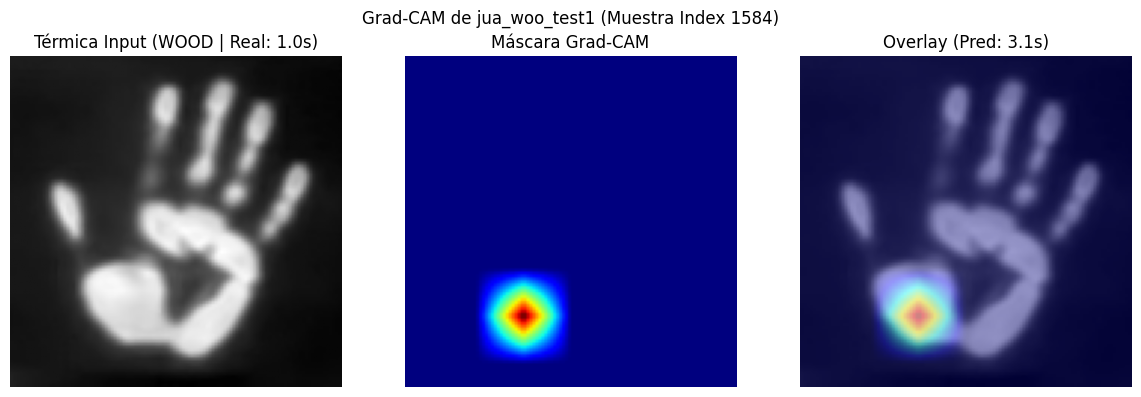

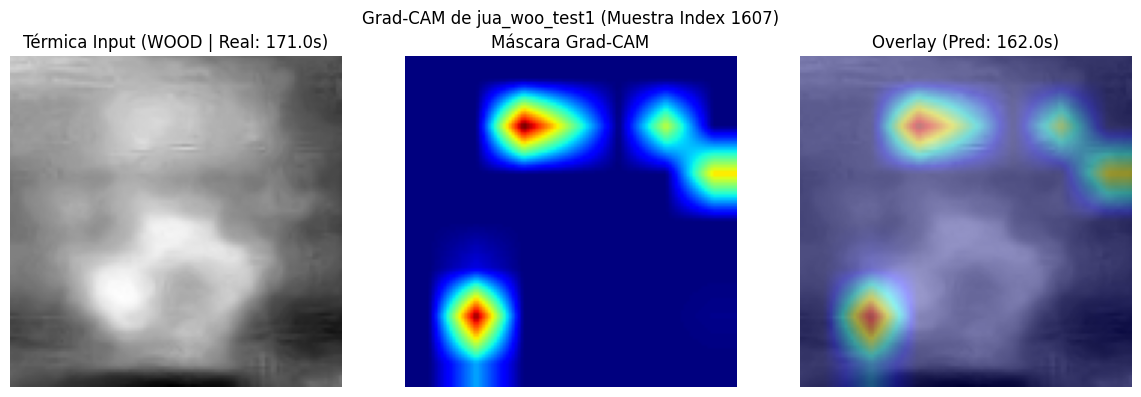

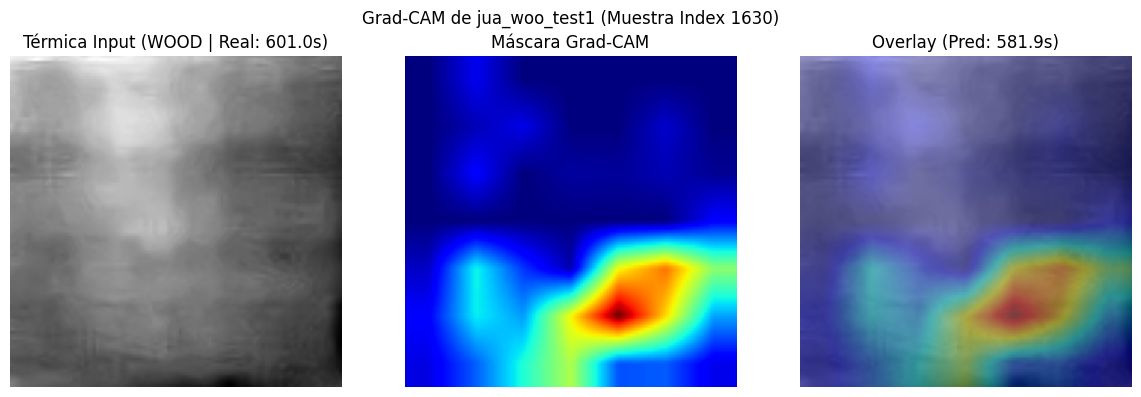

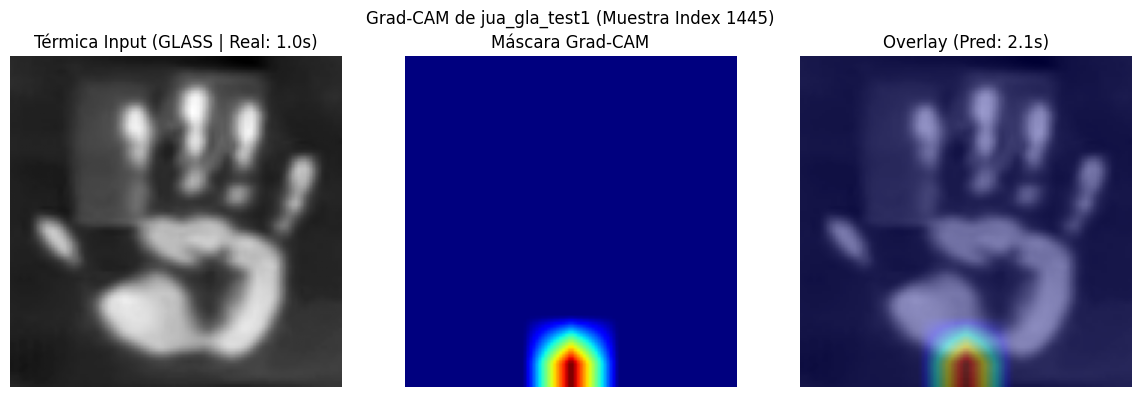

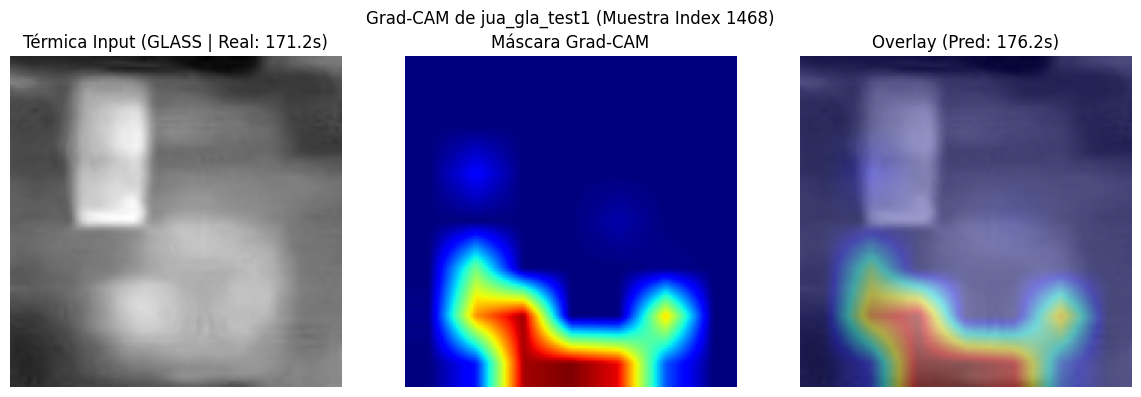

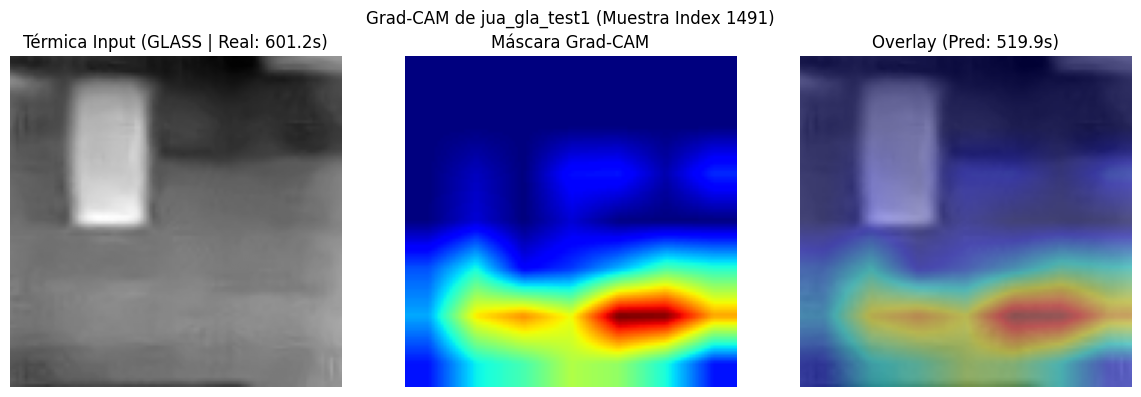

In [4]:
target_layer = model.stage4
gradcam = GradCAM(model, target_layer)

# Buscar índices correspondientes a las secuencias completas de madera y vidrio de Juandiego
indices_wood = val_dataset.df[val_dataset.df["sequence_id"] == "jua_woo_test1"].index.tolist()
indices_glass = val_dataset.df[val_dataset.df["sequence_id"] == "jua_gla_test1"].index.tolist()

print(f"Frames disponibles en validación para madera (jua_woo_test1): {len(indices_wood)}")
print(f"Frames disponibles en validación para vidrio (jua_gla_test1): {len(indices_glass)}")

# Seleccionamos el inicio (t~1s), la mitad (t~100s) y el final (t~601s) de cada secuencia
indices_to_test = []
if indices_wood:
    indices_to_test.extend([indices_wood[0], indices_wood[len(indices_wood)//2], indices_wood[-1]])
if indices_glass:
    indices_to_test.extend([indices_glass[0], indices_glass[len(indices_glass)//2], indices_glass[-1]])

for idx in indices_to_test:
    # Obtener muestra del dataset
    x_img, x_tab, y_time = val_dataset[idx]
    row_meta = val_dataset.df.iloc[idx]
    seq_name = row_meta["sequence_id"]
    surf_name = row_meta["surface"]
    
    # Agregar dimensión batch e indicar dispositivo
    x_img_tensor = x_img.unsqueeze(0).to(device)
    x_tab_tensor = x_tab.unsqueeze(0).to(device)
    
    # Ejecutar Grad-CAM
    cam_mask, pred = gradcam(x_img_tensor, x_tab_tensor)
    
    # Mapear valores escalados a reales (segundos)
    pred_time_s = pred.item() * val_dataset.time_scale
    real_time_s = y_time.item() * val_dataset.time_scale
    
    # Convertir a numpy para graficar
    img_np = x_img.squeeze().numpy()
    # Desnormalizar la imagen del dataset para visualización
    img_vis = ((img_np + 1.0) / 2.0 * 255).astype(np.uint8)
    
    cam_np = cam_mask.squeeze().cpu().numpy()
    # Redimensionar la máscara Grad-CAM al tamaño original
    cam_resize = cv2.resize(cam_np, (img_vis.shape[1], img_vis.shape[0]))
    
    # Crear mapa a color
    cam_u8 = (255 * cam_resize).astype(np.uint8)
    heatmap = cv2.applyColorMap(cam_u8, cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
    
    # Superponer la máscara en la imagen original
    overlay = cv2.addWeighted(cv2.cvtColor(img_vis, cv2.COLOR_GRAY2RGB), 0.6, heatmap, 0.4, 0)
    
    # Graficar
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    
    axes[0].imshow(img_vis, cmap='gray')
    axes[0].set_title(f"Térmica Input ({surf_name.upper()} | Real: {real_time_s:.1f}s)")
    axes[0].axis('off')
    
    axes[1].imshow(cam_resize, cmap='jet')
    axes[1].set_title("Máscara Grad-CAM")
    axes[1].axis('off')
    
    axes[2].imshow(overlay)
    axes[2].set_title(f"Overlay (Pred: {pred_time_s:.1f}s)")
    axes[2].axis('off')
    
    plt.suptitle(f"Grad-CAM de {seq_name} (Muestra Index {idx})", fontsize=12)
    plt.tight_layout()
    plt.show()

# Remover hooks al terminar
gradcam.remove_hooks()

## Análisis de Resultados
1. **¿El modelo se enfoca en la huella?** Si la región de color rojo en la máscara coincide con la zona central (donde está el calor residual del contacto de la mano), significa que el modelo ha aprendido la relación de causa-efecto entre el calor disipado y el tiempo transcurrido.
2. **¿Se enfoca en los bordes?** Si los gradientes más fuertes se concentran en los bordes del recorte o del ROI, esto indica que el modelo está usando bordes geométricos como "atajo" de predicción, lo cual es una señal de sobreajuste (shortcut learning) que debe solucionarse con aumentos de datos o regularización.